In [1]:
# ========== 1. IMPORT THƯ VIỆN ========== #
import os
import numpy as np
import tensorflow as tf   # <- tf phải được tạo trước
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2026-02-28 04:49:28.619391: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772254168.801221      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772254168.852784      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772254169.266763      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772254169.266814      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772254169.266818      55 computation_placer.cc:177] computation placer alr

In [2]:
# ========== GPU CONFIG (KAGGLE) ========== #
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready ✅")
    except RuntimeError as e:
        print(e)

# confirm mixed precision
print("Compute dtype:", tf.keras.mixed_precision.global_policy().compute_dtype)
print("Variable dtype:", tf.keras.mixed_precision.global_policy().variable_dtype)

TensorFlow version: 2.19.0
Num GPUs Available: 2
GPU is ready ✅
Compute dtype: float32
Variable dtype: float32


In [3]:
## MobileNetV2 21-06
# ========== 1. IMPORT THƯ VIỆN ========== #
import os
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
print(f"Random seed set to: {RANDOM_SEED}")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from tensorflow.keras.regularizers import l2

# ========== 2. THIẾT LẬP MIXED PRECISION ========== #
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# ========== 3. DATA PATH & AUGMENTATION ========== #
DATA_DIR = "/kaggle/input/datasets/usertesttttt1/dataset-garlic-2106/dataset_final_2006"
RESULT_DIR = "/kaggle/working/report_MobileNetV2_2809"
os.makedirs(RESULT_DIR, exist_ok=True)

def create_generators(data_dir, input_size, batch_size=32):
    train_datagen = ImageDataGenerator(
        preprocessing_function=mobilenet_preprocess,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.7, 1.3],
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

    train_gen = train_datagen.flow_from_directory(
        os.path.join(data_dir, 'train'),
        target_size=input_size,
        batch_size=batch_size,
        class_mode='categorical'
    )
    val_gen = val_datagen.flow_from_directory(
        os.path.join(data_dir, 'val'),
        target_size=input_size,
        batch_size=batch_size,
        class_mode='categorical'
    )
    test_gen = val_datagen.flow_from_directory(
        os.path.join(data_dir, 'test'),
        target_size=input_size,
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False
    )
    return train_gen, val_gen, test_gen

# ========== 4. LOAD DATA ========== #
input_shape = (224, 224, 3)  # MobileNetV2 default input size
batch_size = 32
train_generator, val_generator, test_generator = create_generators(
    DATA_DIR, input_shape[:2], batch_size
)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

# ========== 5. XÂY DỰNG VÀ TRAIN MÔ HÌNH MobileNetV2 ========== #
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
# Nếu False: freeze toàn bộ base_model, chỉ train head; True: unfreeze để fine-tune
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-5))(x)
x = Dropout(0.5)(x)
outputs = Dense(len(train_generator.class_indices), activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# ========== 6. COMPILE ========== #
epochs = 30
steps_per_epoch = train_generator.samples // batch_size
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-5,
    decay_steps=steps_per_epoch * 5,
    decay_rate=0.9,
    staircase=True
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.15),
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    CSVLogger(os.path.join(RESULT_DIR, 'training_log.csv'), append=False),
    ModelCheckpoint(os.path.join(RESULT_DIR, 'mobilenetv2_best.keras'),
                    save_best_only=True, monitor='val_loss', verbose=1)
]

# ========== 7. TRAIN ========== #
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs,
    class_weight=class_weights,
    callbacks=callbacks
)

Random seed set to: 42
Found 2334 images belonging to 3 classes.
Found 500 images belonging to 3 classes.
Found 500 images belonging to 3 classes.


I0000 00:00:1772254196.073164      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772254196.079195      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1772254207.803528     144 service.cc:152] XLA service 0x792c000039c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772254207.803561     144 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772254207.803565     144 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772254209.056126     144 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772254224.992795     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3791 - loss: 1.6549
Epoch 1: val_loss improved from inf to 1.13121, saving model to /kaggle/working/report_MobileNetV2_2809/mobilenetv2_best.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - accuracy: 0.3795 - loss: 1.6539 - val_accuracy: 0.5060 - val_loss: 1.1312
Epoch 2/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 945ms/step - accuracy: 0.4573 - loss: 1.4818
Epoch 2: val_loss improved from 1.13121 to 1.02843, saving model to /kaggle/working/report_MobileNetV2_2809/mobilenetv2_best.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.4576 - loss: 1.4812 - val_accuracy: 0.5740 - val_loss: 1.0284
Epoch 3/30
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5210 - loss: 1.3320
Epoch 3: val_loss improved from 1.02843 to 0.98276, saving model to /kaggle/working/report_MobileNetV2_2809/mobilenetv2_best.keras
73/73 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5211 - loss: 1.3315 - val_accuracy: 0.6160 - val_loss: 0.9828
Epoch 4/30
73/73 ━━━━━━━

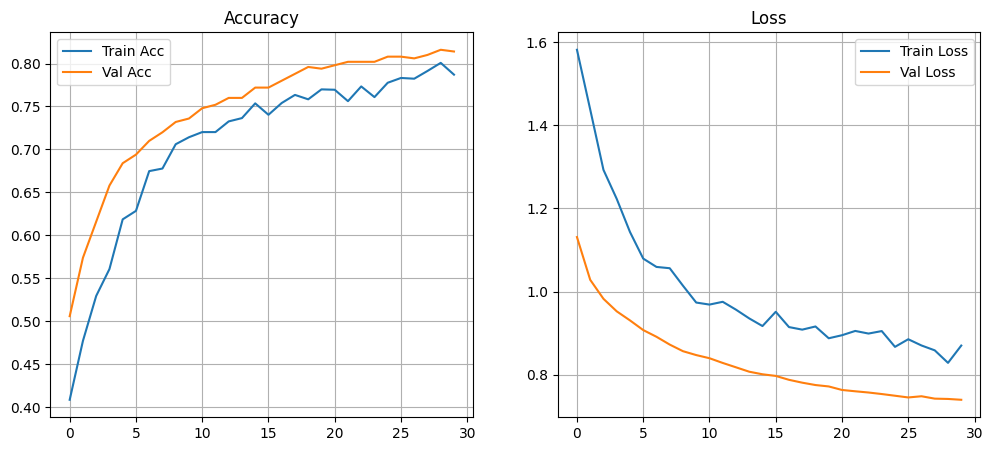

In [4]:
# ========== LEARNING CURVES ========== #
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.grid()

plt.savefig(os.path.join(RESULT_DIR, "learning_curve.png"), dpi=300)
plt.show()

In [5]:
# ========== LOAD BEST MODEL ========== #
model = load_model(os.path.join(RESULT_DIR, 'mobilenetv2_best.keras'))

# predict
pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

16/16 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step


In [6]:
# ========== CLASSIFICATION REPORT ========== #
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

with open(os.path.join(RESULT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

                         precision    recall  f1-score   support

           clean_garlic     0.8417    0.7548    0.7959       155
partially_peeled_garlic     0.8971    0.9037    0.9004       135
          rotten_garlic     0.8133    0.8714    0.8414       210

               accuracy                         0.8440       500
              macro avg     0.8507    0.8433    0.8459       500
           weighted avg     0.8447    0.8440    0.8432       500



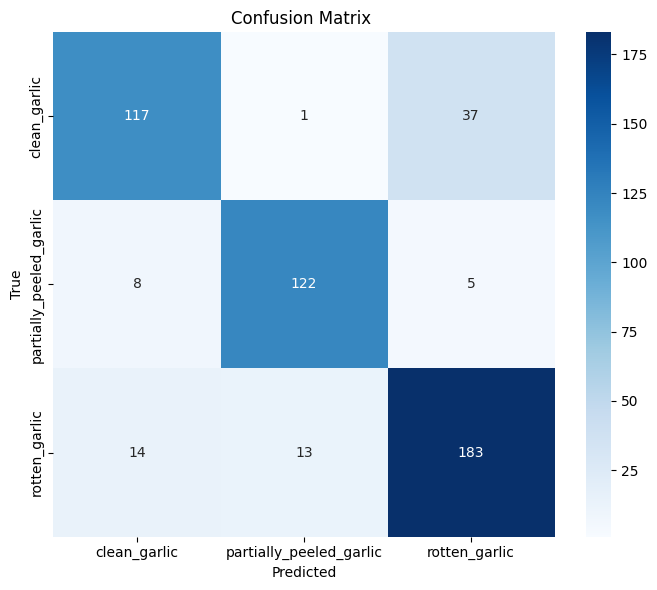

In [7]:
# ========== CONFUSION MATRIX ========== #
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix ")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "confusion_matrix.png"), dpi=300)
plt.show()

In [8]:
# ========== LOAD BEST MODEL ========== #
model = load_model(os.path.join(RESULT_DIR, 'mobilenetv2_best.keras'))

# reset generator (quan trọng)
test_generator.reset()

# predict
pred_probs = model.predict(test_generator, verbose=1)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print("Total test samples:", len(y_true))

16/16 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step 
Total test samples: 500


In [9]:
test_acc = np.mean(y_pred == y_true)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.844


In [10]:
# ========== PREPARE PATHS ========== #
test_dir = os.path.join(DATA_DIR, "test")
filepaths = [os.path.join(test_dir, f) for f in test_generator.filenames]

In [11]:
# ========== FIND CONFUSION TYPES ========== #
from collections import defaultdict

confusion_dict = defaultdict(list)

for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        key = (class_names[y_true[i]], class_names[y_pred[i]])
        confidence = pred_probs[i][y_pred[i]]
        confusion_dict[key].append((filepaths[i], confidence, i))

print("Total confusion types:", len(confusion_dict))

Total confusion types: 6


In [12]:
# ========== SELECT REPRESENTATIVE IMAGES ========== #
import shutil

analysis_dir = os.path.join(RESULT_DIR, "qualitative_analysis")
os.makedirs(analysis_dir, exist_ok=True)

summary_lines = []

for (true_label, pred_label), samples in confusion_dict.items():

    # sort theo độ tự tin giảm dần
    samples_sorted = sorted(samples, key=lambda x: x[1], reverse=True)

    selected = samples_sorted[:10]  # lấy 2 ảnh

    pair_folder = os.path.join(analysis_dir, f"{true_label}_as_{pred_label}")
    os.makedirs(pair_folder, exist_ok=True)

    summary_lines.append(f"\n=== {true_label} → {pred_label} ===")

    for idx, (img_path, conf, i) in enumerate(selected):
        new_name = f"sample_{idx+1}_conf_{conf:.3f}.jpg"
        dst = os.path.join(pair_folder, new_name)
        shutil.copy(img_path, dst)

        summary_lines.append(f"{new_name} | confidence={conf:.3f}")

In [13]:
with open(os.path.join(analysis_dir, "analysis_notes.txt"), "w") as f:
    f.write("\n".join(summary_lines))

print("Saved qualitative analysis samples")

Saved qualitative analysis samples


In [14]:
!cd /kaggle/working/report_MobileNetV2_2809/qualitative_analysis && zip -r /kaggle/working/qualitative_analysis.zip .

  adding: partially_peeled_garlic_as_clean_garlic/ (stored 0%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_4_conf_0.882.jpg (deflated 2%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_7_conf_0.512.jpg (deflated 1%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_8_conf_0.444.jpg (deflated 2%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_3_conf_0.929.jpg (deflated 1%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_6_conf_0.625.jpg (deflated 0%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_2_conf_0.952.jpg (deflated 1%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_1_conf_0.954.jpg (deflated 1%)
  adding: partially_peeled_garlic_as_clean_garlic/sample_5_conf_0.841.jpg (deflated 1%)
  adding: analysis_notes.txt (deflated 82%)
  adding: rotten_garlic_as_partially_peeled_garlic/ (stored 0%)
  adding: rotten_garlic_as_partially_peeled_garlic/sample_6_conf_0.637.jpg (deflated 2%)
  adding: rotten_garlic_as_partially

# ========== MODEL ANALYSIS & REPORTS ========== #

In [15]:
# ========== MODEL SUMMARY & PARAMETERS ========== #
model.summary()

# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = total_params - trainable_params

print("\n" + "="*60)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable params: {non_trainable_params:,}")
print("="*60)

# Save to file
with open(os.path.join(RESULT_DIR, "model_summary.txt"), "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
    f.write("\n" + "="*60 + "\n")
    f.write(f"Total params: {total_params:,}\n")
    f.write(f"Trainable params: {trainable_params:,}\n")
    f.write(f"Non-trainable params: {non_trainable_params:,}\n")
    f.write("="*60 + "\n")

print("✅ Model summary saved")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,761,294 (10.53 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

 Optimizer params: 333,835 (1.27 MB)


Total params: 2,427,459
Trainable params: 166,915
Non-trainable params: 2,260,544


✅ Model summary saved


In [16]:
# ========== MODEL SIZE ========== #
import tempfile

# Save model temporarily to get size
temp_model_path = os.path.join(tempfile.gettempdir(), "temp_model.keras")
model.save(temp_model_path)
model_size_bytes = os.path.getsize(temp_model_path)
model_size_mb = model_size_bytes / (1024 * 1024)

print("="*60)
print(f"Model size: {model_size_mb:.2f} MB ({model_size_bytes:,} bytes)")
print("="*60)

# Save to file
with open(os.path.join(RESULT_DIR, "model_size.txt"), "w", encoding="utf-8") as f:
    f.write("="*60 + "\n")
    f.write(f"Model size: {model_size_mb:.2f} MB ({model_size_bytes:,} bytes)\n")
    f.write("="*60 + "\n")

# Clean up
os.remove(temp_model_path)
print("✅ Model size saved")

Model size: 12.38 MB (12,978,639 bytes)
✅ Model size saved


In [17]:
# ========== INFERENCE SPEED ========== #
import time

# Warm-up: run a few predictions to initialize
print("Warming up...")
test_generator.reset()
warmup_batch = next(test_generator)[0][:5]  # 5 images
for _ in range(3):
    _ = model.predict(warmup_batch, verbose=0)

# Measure inference time on multiple batches
print("\nMeasuring inference speed...")
test_generator.reset()
num_test_batches = 10
total_images = 0
total_time = 0

for i in range(num_test_batches):
    batch_x, _ = next(test_generator)
    batch_size_actual = len(batch_x)
    
    start_time = time.time()
    _ = model.predict(batch_x, verbose=0)
    end_time = time.time()
    
    total_images += batch_size_actual
    total_time += (end_time - start_time)

# Calculate metrics
avg_time_per_image = (total_time / total_images) * 1000  # ms
fps = total_images / total_time

print("\n" + "="*60)
print("Inference Speed:")
print(f"  FPS: {fps:.2f}")
print(f"  ms/image: {avg_time_per_image:.2f}")
print(f"  Total images tested: {total_images}")
print(f"  Total time: {total_time:.3f}s")
print("="*60)

# Save to file
with open(os.path.join(RESULT_DIR, "inference_speed.txt"), "w", encoding="utf-8") as f:
    f.write("="*60 + "\n")
    f.write("Inference Speed:\n")
    f.write(f"  FPS: {fps:.2f}\n")
    f.write(f"  ms/image: {avg_time_per_image:.2f}\n")
    f.write(f"  Total images tested: {total_images}\n")
    f.write(f"  Total time: {total_time:.3f}s\n")
    f.write("="*60 + "\n")

print("✅ Inference speed saved")

Warming up...

Measuring inference speed...

Inference Speed:
  FPS: 25.18
  ms/image: 39.72
  Total images tested: 320
  Total time: 12.710s
✅ Inference speed saved


In [18]:
# ========== TOP-K ACCURACY ========== #
from sklearn.metrics import top_k_accuracy_score

top_1_acc = top_k_accuracy_score(y_true, pred_probs, k=1, labels=range(len(class_names)))
top_3_acc = top_k_accuracy_score(y_true, pred_probs, k=3, labels=range(len(class_names)))
top_5_acc = top_k_accuracy_score(y_true, pred_probs, k=5, labels=range(len(class_names)))

print("\n" + "="*60)
print("Top-K Accuracy:")
print(f"  Top-1 Accuracy: {top_1_acc:.4f} ({top_1_acc*100:.2f}%)")
print(f"  Top-3 Accuracy: {top_3_acc:.4f} ({top_3_acc*100:.2f}%)")
print(f"  Top-5 Accuracy: {top_5_acc:.4f} ({top_5_acc*100:.2f}%)")
print("="*60)

# Save to file
with open(os.path.join(RESULT_DIR, "topk_accuracy.txt"), "w", encoding="utf-8") as f:
    f.write("="*60 + "\n")
    f.write("Top-K Accuracy:\n")
    f.write(f"  Top-1 Accuracy: {top_1_acc:.4f} ({top_1_acc*100:.2f}%)\n")
    f.write(f"  Top-3 Accuracy: {top_3_acc:.4f} ({top_3_acc*100:.2f}%)\n")
    f.write(f"  Top-5 Accuracy: {top_5_acc:.4f} ({top_5_acc*100:.2f}%)\n")
    f.write("="*60 + "\n")

print("✅ Top-K accuracy saved")


Top-K Accuracy:
  Top-1 Accuracy: 0.8440 (84.40%)
  Top-3 Accuracy: 1.0000 (100.00%)
  Top-5 Accuracy: 1.0000 (100.00%)
✅ Top-K accuracy saved


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (3) greater than or equal to 'n_classes' (3) will result in a perfect score and is therefore meaningless.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:2036: UndefinedMetricWarning: 'k' (5) greater than or equal to 'n_classes' (3) will result in a perfect score and is therefore meaningless.
  warnings.warn(


In [19]:
# ========== PER-CLASS ACCURACY ========== #
from sklearn.metrics import classification_report

# Get per-class metrics
report_dict = classification_report(y_true, y_pred, target_names=class_names, 
                                   output_dict=True, digits=4)

# Create per-class accuracy dataframe
per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': [report_dict[c]['precision'] for c in class_names],
    'Recall': [report_dict[c]['recall'] for c in class_names],
    'F1-Score': [report_dict[c]['f1-score'] for c in class_names],
    'Support': [report_dict[c]['support'] for c in class_names]
})

print("\n" + "="*60)
print("Per-Class Metrics:")
print(per_class_df.to_string(index=False))
print("="*60)

# Save to CSV
per_class_df.to_csv(os.path.join(RESULT_DIR, "per_class_metrics.csv"), index=False)
print("✅ Per-class metrics saved")


Per-Class Metrics:
                  Class  Precision   Recall  F1-Score  Support
           clean_garlic   0.841727 0.754839  0.795918    155.0
partially_peeled_garlic   0.897059 0.903704  0.900369    135.0
          rotten_garlic   0.813333 0.871429  0.841379    210.0
✅ Per-class metrics saved


In [20]:
# ========== PREDICTIONS CSV ========== #
# Create detailed predictions dataframe
predictions_df = pd.DataFrame({
    'filename': test_generator.filenames,
    'true_label': [class_names[i] for i in y_true],
    'predicted_label': [class_names[i] for i in y_pred],
    'correct': y_true == y_pred,
    'confidence': [pred_probs[i][y_pred[i]] for i in range(len(y_pred))]
})

# Add top-3 predictions for each image
for k in range(min(3, len(class_names))):
    top_k_indices = np.argsort(pred_probs, axis=1)[:, -(k+1)]
    predictions_df[f'top_{k+1}_class'] = [class_names[i] for i in top_k_indices]
    predictions_df[f'top_{k+1}_prob'] = [pred_probs[i][top_k_indices[i]] for i in range(len(pred_probs))]

# Save to CSV
predictions_df.to_csv(os.path.join(RESULT_DIR, "predictions_detail.csv"), index=False)

print(f"✅ Predictions CSV saved ({len(predictions_df)} samples)")
print(f"   Correct predictions: {predictions_df['correct'].sum()}")
print(f"   Incorrect predictions: {(~predictions_df['correct']).sum()}")

✅ Predictions CSV saved (500 samples)
   Correct predictions: 422
   Incorrect predictions: 78


In [21]:
# ========== COMPREHENSIVE SUMMARY REPORT ========== #
summary_report = []
summary_report.append("="*80)
summary_report.append("MobileNetV2 - COMPREHENSIVE EVALUATION REPORT")
summary_report.append("="*80)
summary_report.append(f"\nDataset: {DATA_DIR}")
summary_report.append(f"Result Directory: {RESULT_DIR}")
summary_report.append(f"Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")

summary_report.append("\n" + "-"*80)
summary_report.append("MODEL CONFIGURATION")
summary_report.append("-"*80)
summary_report.append(f"Architecture: MobileNetV2")
summary_report.append(f"Input Shape: {input_shape}")
summary_report.append(f"Number of Classes: {len(class_names)}")
summary_report.append(f"Classes: {', '.join(class_names)}")
summary_report.append(f"\nTotal Parameters: {total_params:,}")
summary_report.append(f"Trainable Parameters: {trainable_params:,}")
summary_report.append(f"Non-trainable Parameters: {non_trainable_params:,}")
summary_report.append(f"Model Size: {model_size_mb:.2f} MB")

summary_report.append("\n" + "-"*80)
summary_report.append("DATASET STATISTICS")
summary_report.append("-"*80)
summary_report.append(f"Training Samples: {train_generator.samples}")
summary_report.append(f"Validation Samples: {val_generator.samples}")
summary_report.append(f"Test Samples: {test_generator.samples}")

summary_report.append("\n" + "-"*80)
summary_report.append("TRAINING CONFIGURATION")
summary_report.append("-"*80)
summary_report.append(f"Batch Size: {batch_size}")
summary_report.append(f"Total Epochs: {len(history.history['loss'])}")
summary_report.append(f"Initial Learning Rate: 1e-5")
summary_report.append(f"Optimizer: Adam with ExponentialDecay")
summary_report.append(f"Loss Function: CategoricalCrossentropy (label_smoothing=0.15)")
summary_report.append(f"Class Weights: Balanced")

summary_report.append("\n" + "-"*80)
summary_report.append("PERFORMANCE METRICS")
summary_report.append("-"*80)
summary_report.append(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
summary_report.append(f"Top-1 Accuracy: {top_1_acc:.4f} ({top_1_acc*100:.2f}%)")
summary_report.append(f"Top-3 Accuracy: {top_3_acc:.4f} ({top_3_acc*100:.2f}%)")
summary_report.append(f"Top-5 Accuracy: {top_5_acc:.4f} ({top_5_acc*100:.2f}%)")

summary_report.append("\n" + "-"*80)
summary_report.append("INFERENCE SPEED")
summary_report.append("-"*80)
summary_report.append(f"FPS: {fps:.2f}")
summary_report.append(f"ms/image: {avg_time_per_image:.2f}")

summary_report.append("\n" + "-"*80)
summary_report.append("BEST TRAINING EPOCH METRICS")
summary_report.append("-"*80)
best_val_loss_idx = np.argmin(history.history['val_loss'])
summary_report.append(f"Best Epoch: {best_val_loss_idx + 1}")
summary_report.append(f"  Train Loss: {history.history['loss'][best_val_loss_idx]:.4f}")
summary_report.append(f"  Train Accuracy: {history.history['accuracy'][best_val_loss_idx]:.4f}")
summary_report.append(f"  Val Loss: {history.history['val_loss'][best_val_loss_idx]:.4f}")
summary_report.append(f"  Val Accuracy: {history.history['val_accuracy'][best_val_loss_idx]:.4f}")

summary_report.append("\n" + "="*80)
summary_report.append("END OF REPORT")
summary_report.append("="*80)

# Print and save
summary_text = "\n".join(summary_report)
print(summary_text)

with open(os.path.join(RESULT_DIR, "SUMMARY_REPORT.txt"), "w", encoding="utf-8") as f:
    f.write(summary_text)

print("\n✅ Comprehensive summary report saved")

MobileNetV2 - COMPREHENSIVE EVALUATION REPORT

Dataset: /kaggle/input/datasets/usertesttttt1/dataset-garlic-2106/dataset_final_2006
Result Directory: /kaggle/working/report_MobileNetV2_2809
Training Date: 2026-02-28 05:38:33

--------------------------------------------------------------------------------
MODEL CONFIGURATION
--------------------------------------------------------------------------------
Architecture: MobileNetV2
Input Shape: (224, 224, 3)
Number of Classes: 3
Classes: clean_garlic, partially_peeled_garlic, rotten_garlic

Total Parameters: 2,427,459
Trainable Parameters: 166,915
Non-trainable Parameters: 2,260,544
Model Size: 12.38 MB

--------------------------------------------------------------------------------
DATASET STATISTICS
--------------------------------------------------------------------------------
Training Samples: 2334
Validation Samples: 500
Test Samples: 500

--------------------------------------------------------------------------------
TRAINING CO

In [22]:
# ========== LIST ALL REPORT FILES ========== #
import glob

print("\n" + "="*80)
print("GENERATED REPORT FILES:")
print("="*80)

all_files = glob.glob(os.path.join(RESULT_DIR, "*"))
for file_path in sorted(all_files):
    if os.path.isfile(file_path):
        file_name = os.path.basename(file_path)
        file_size = os.path.getsize(file_path)
        if file_size < 1024:
            size_str = f"{file_size} B"
        elif file_size < 1024*1024:
            size_str = f"{file_size/1024:.2f} KB"
        else:
            size_str = f"{file_size/(1024*1024):.2f} MB"
        print(f"  ✓ {file_name:40s} ({size_str})")
    elif os.path.isdir(file_path):
        dir_name = os.path.basename(file_path)
        num_files = len([f for f in glob.glob(os.path.join(file_path, "**/*"), recursive=True) if os.path.isfile(f)])
        print(f"  📁 {dir_name:40s} ({num_files} files)")

print("="*80)


GENERATED REPORT FILES:
  ✓ SUMMARY_REPORT.txt                       (2.37 KB)
  ✓ classification_report.txt                (457 B)
  ✓ confusion_matrix.png                     (106.42 KB)
  ✓ inference_speed.txt                      (219 B)
  ✓ learning_curve.png                       (187.43 KB)
  ✓ mobilenetv2_best.keras                   (12.38 MB)
  ✓ model_size.txt                           (162 B)
  ✓ model_summary.txt                        (63.71 KB)
  ✓ per_class_metrics.csv                    (279 B)
  ✓ predictions_detail.csv                   (79.76 KB)
  📁 qualitative_analysis                     (45 files)
  ✓ topk_accuracy.txt                        (242 B)
  ✓ training_log.csv                         (2.37 KB)


In [23]:
# ========== ZIP ALL REPORTS ========== #
import shutil

zip_output_path = "/kaggle/working/MobileNetV2_Complete_Report"
print(f"\n🗜️  Creating complete report archive...")
print(f"Source: {RESULT_DIR}")
print(f"Output: {zip_output_path}.zip")

# Create zip file
shutil.make_archive(zip_output_path, 'zip', RESULT_DIR)

zip_size = os.path.getsize(f"{zip_output_path}.zip") / (1024*1024)
print(f"\n✅ Complete report archived successfully!")
print(f"📦 Archive size: {zip_size:.2f} MB")
print(f"📍 Location: {zip_output_path}.zip")
print("\n" + "="*80)
print("ARCHIVE CONTENTS:")
print("  ✓ SUMMARY_REPORT.txt - Comprehensive evaluation summary")
print("  ✓ model_summary.txt - Model architecture & parameters")
print("  ✓ model_size.txt - Model file size")
print("  ✓ inference_speed.txt - FPS & latency metrics")
print("  ✓ topk_accuracy.txt - Top-1, Top-3, Top-5 accuracy")
print("  ✓ classification_report.txt - Precision, Recall, F1 per class")
print("  ✓ per_class_metrics.csv - Detailed class metrics")
print("  ✓ predictions_detail.csv - All predictions with confidence")
print("  ✓ training_log.csv - Training history")
print("  ✓ learning_curve.png - Training visualization")
print("  ✓ confusion_matrix.png - Confusion matrix heatmap")
print("  ✓ mobilenetv2_best.keras - Best model weights")
print("  📁 qualitative_analysis/ - Misclassified samples analysis")
print("="*80)


🗜️  Creating complete report archive...
Source: /kaggle/working/report_MobileNetV2_2809
Output: /kaggle/working/MobileNetV2_Complete_Report.zip

✅ Complete report archived successfully!
📦 Archive size: 39.80 MB
📍 Location: /kaggle/working/MobileNetV2_Complete_Report.zip

ARCHIVE CONTENTS:
  ✓ SUMMARY_REPORT.txt - Comprehensive evaluation summary
  ✓ model_summary.txt - Model architecture & parameters
  ✓ model_size.txt - Model file size
  ✓ inference_speed.txt - FPS & latency metrics
  ✓ topk_accuracy.txt - Top-1, Top-3, Top-5 accuracy
  ✓ classification_report.txt - Precision, Recall, F1 per class
  ✓ per_class_metrics.csv - Detailed class metrics
  ✓ predictions_detail.csv - All predictions with confidence
  ✓ training_log.csv - Training history
  ✓ learning_curve.png - Training visualization
  ✓ confusion_matrix.png - Confusion matrix heatmap
  ✓ mobilenetv2_best.keras - Best model weights
  📁 qualitative_analysis/ - Misclassified samples analysis
